# NOTEBOOK EDA

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Nitropc\Documents\Github\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_eda.csv")

In [3]:
def convert_to_datetime(df):
    date_regex = r'^(?:(?:\d{4}[-/]\d{1,2}[-/]\d{1,2})|(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}))(?:[\sT]+(?:[01]?\d|2[0-3]):[0-5]\d(?::[0-5]\d)?)?$'

    for col in df.columns:
        if df[col].dtype.name == 'object':
            mask = df[col].dropna().str.match(date_regex)
            if mask.all():
                df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)

    return df

In [4]:
def convert_categorical(df):
    age_order = ['less than 25', '25-45', '46-65', 'greater than 65']
    score_order = ['low', 'medium', 'high']
    charge_degree_order = ["misdemeanor", "felony"]


    df["age_cat"] = pd.Categorical(df["age_cat"], categories= age_order, ordered=True)
    df["score_text"] = pd.Categorical(df["score_text"], categories= score_order, ordered=True)
    df["c_charge_degree"] = pd.Categorical(df["c_charge_degree"], categories= charge_degree_order, ordered=True)


    return df

In [5]:
df.columns

Index(['sex', 'age', 'age_cat', 'decile_score', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'score_text', 'screening_date', 'two_year_recid',
       'priors_count', 'c_charge_degree', 'start', 'end', 'event', 'person_id',
       'agency_text', 'ethnic_code_text', 'maritalstatus', 'language'],
      dtype='object')

In [6]:
df["score_text"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [7]:
df = convert_to_datetime(df)

In [8]:
df = convert_categorical(df)

## Guión


### -Sacar gráficos
    - Estadísticos descriptivos de las variables
    - .corr de scores y demográficas
    - is_recid y is_v_recid con demográficas
    - cantidad de falsos positivos y falsos negativos + porcentaje de acierto del score
    - Tablas de contigencias de variables demográficas sobre is_recid y v_is_recid y score intervalos

In [17]:
# En bar plot (plotly), animation_frame para la barra interactuable
def eda(df):
    lista_variables_numericas = df.select_dtypes(include = "number").columns.tolist()
    lista_variables_numericas.remove("person_id")
    lista_variables_categoricas = df.select_dtypes(include = ["object", "category"]).columns.tolist()
    lista_variables_temporales = df.select_dtypes(include = "datetime").columns.tolist()
    lista_booleanos = df[["is_recid", "is_violent_recid"]].columns.tolist()
    lista_chi2 = lista_variables_categoricas + lista_booleanos
    
    display(Markdown("# Análisis univariable"))

    for col in lista_variables_categoricas:
    # Sacamos valores únicos y sus conteos
        counts = df[col].value_counts(dropna=False)
        
        if df[col].nunique() <= 3:
            # Preparamos labels con nombre + conteo
            labels = [f'{valor}\n{count}' for valor, count in zip(counts.index, counts.values)]
            
            # Dibujamos el pie chart
            plt.figure()
            plt.pie(
                counts.values,
                labels=labels,
                autopct='%1.1f%%'
            )
            
            plt.title(f'Distribución de {col}')
            plt.show()

        else:
            total = counts.sum()

            df_count = counts.reset_index()
            df_count.columns = [col, "frecuencia"]
            df_count["pct"] = df_count["frecuencia"] / total

            fig = px.bar(
                df_count,
                x=col,
                y='frecuencia',
                text= df_count.apply(
                lambda r: f"{r['pct']:.1%}",
                axis=1
            ),
            )

            fig.update_layout(
            title=f'Número de personas por {col}',
            yaxis_title='Número de personas'
            )

            fig.show()


    # df["ethnic_code_text"].value_counts().plot(kind="bar")
    # plt.title('Distribucion de personas por raza')
    # plt.show()

    
    print(f"Media:\n{df[lista_variables_numericas].mean()}")
    print("\n")
    print(f"Mediana:\n{df[lista_variables_numericas].median()}")
    print("\n")
    print(f"Mínimo:\n{df[lista_variables_numericas].min()}")
    print("\n")
    print(f"Máximo:\n{df[lista_variables_numericas].max()}")
    print("\n")
    print(f"Varianza:\n{df[lista_variables_numericas].var()}")
    print("\n")
    print(f"Desviación típica:\n{df[lista_variables_numericas].std()}")
    print("\n")
    print(f"Moda:\n{df[lista_variables_numericas].mode()}")

    for col in lista_variables_numericas:
        df[[col]].boxplot(figsize=(8,5))
        plt.title(f"Distribución general de {col}")
        plt.show()
        print("\n")

    display(Markdown("# Análisis bivariable"))
    print("\n")

    for col_num in lista_variables_numericas:
        for col_cat in lista_variables_categoricas:
            if col_cat != "sex":
                sns.boxplot(
                    data= df,
                    x=col_cat,
                    y= col_num,
                    hue="sex"
                )
                plt.title(f"Distribución de {col_num} por género y {col_cat}")
                plt.show()
                print("\n")

    # for col_num1 in lista_variables_numericas:
    #     for col_num2 in lista_variables_numericas:
    #         if col_num1 != col_num2:
    #             sns.relplot(
    #                 data= df,
    #                 x=col_num2,
    #                 y= col_num1,
                    
    #             )
    #             plt.title(f"Distribución de {col_num2} por {col_num1}")
    #             plt.show()
    #             print("\n")



    corr_matrix = df[lista_variables_numericas].corr(method= "spearman")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Matriz de correlación")
    plt.show()

    

 
    # for var in lista_variables_numericas:
    #     sns.lineplot(
    #         data=df,
    #         x="Año",
    #         y=var,
    #         hue="sex",
    #         marker="o"
    #     )
    #     plt.title(f"Evolución temporal de {var}")
    #     plt.xticks(df["Año"].unique())
    #     plt.show()
    #     print("\n")

    for col1, col2 in combinations(lista_chi2, 2):
        tabla = pd.crosstab(df[col1], df[col2], margins= True)
        chi2, p, dof, expected = chi2_contingency(tabla)
        if(p <= 0.05):
            print(f"\nCrosstab entre {col1} y {col2}")
            display(tabla)


In [10]:
# df = df.set_index("person_id")

# Análisis univariable

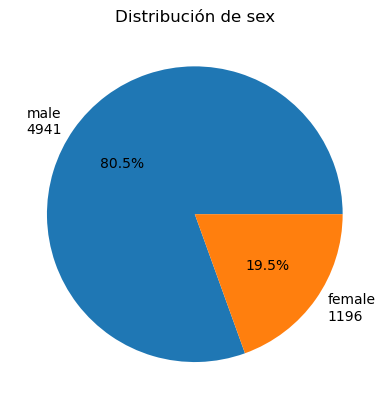

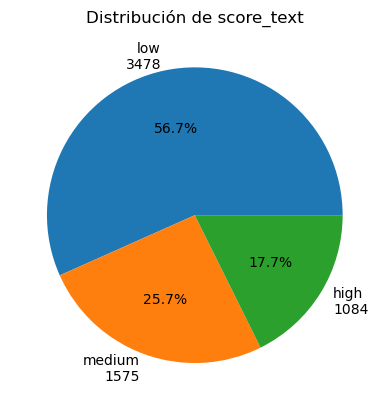

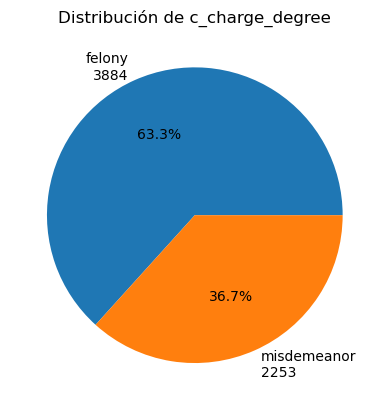

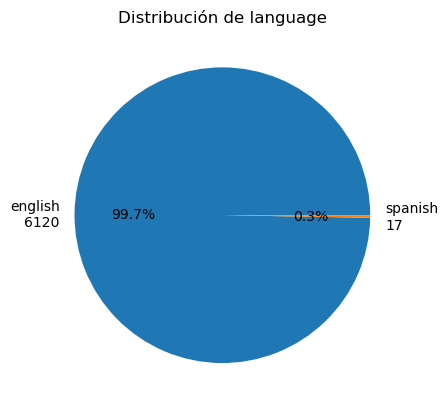

Media:
age                  35.281897
decile_score          4.334528
v_decile_score        3.587258
is_recid              0.397100
is_violent_recid      0.095812
two_year_recid        0.361577
priors_count          3.223399
start                11.876324
end                 612.888056
event                 0.314486
dtype: float64


Mediana:
age                  32.0
decile_score          4.0
v_decile_score        3.0
is_recid              0.0
is_violent_recid      0.0
two_year_recid        0.0
priors_count          1.0
start                 0.0
end                 750.0
event                 0.0
dtype: float64


Mínimo:
age                 19
decile_score         1
v_decile_score       1
is_recid             0
is_violent_recid     0
two_year_recid       0
priors_count         0
start                0
end                  1
event                0
dtype: int64


Máximo:
age                   96
decile_score          10
v_decile_score        10
is_recid               1
is_violent_recid   

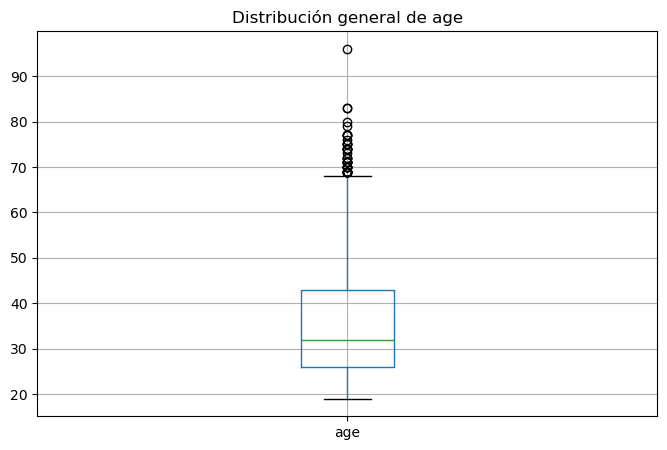

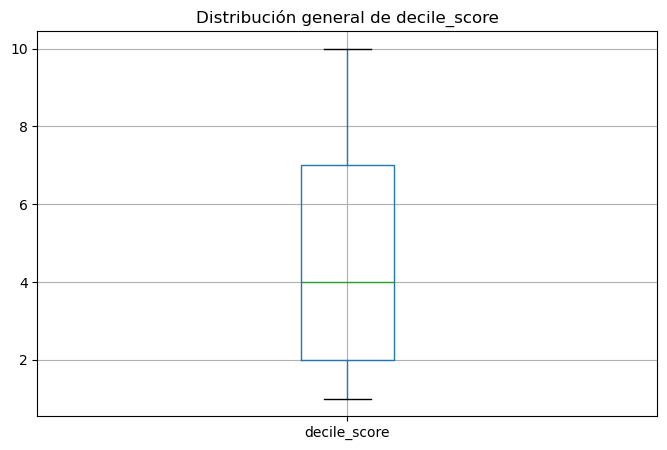

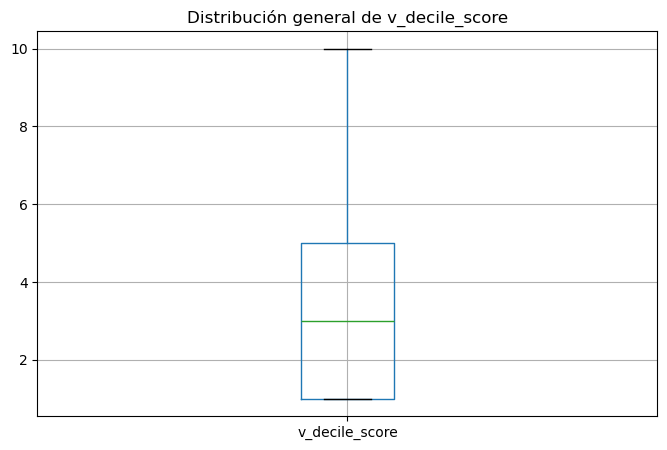

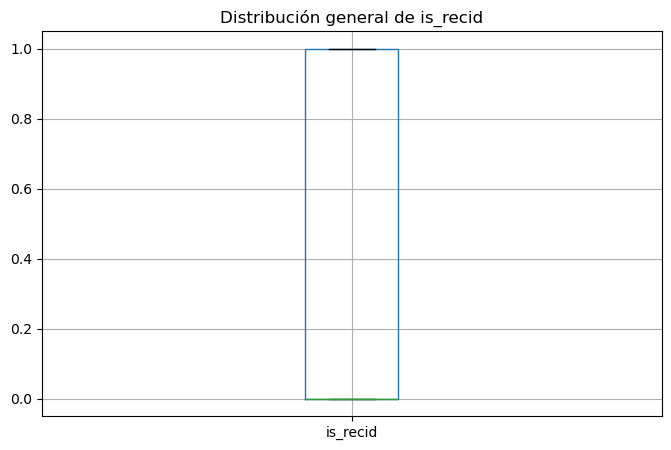

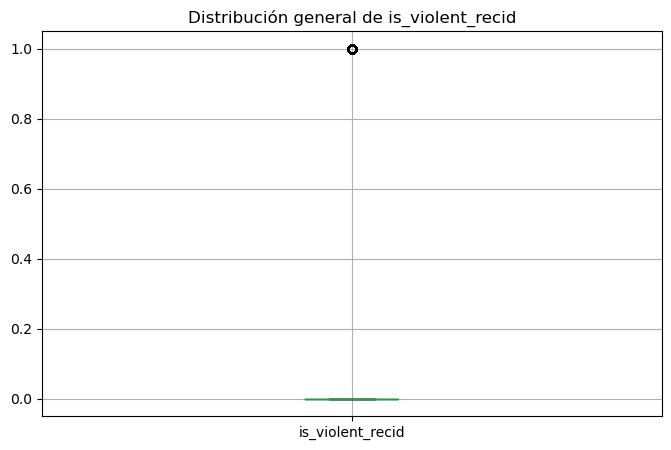

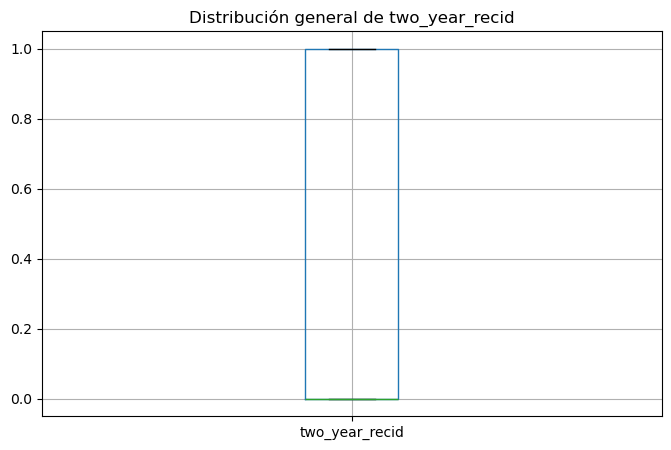

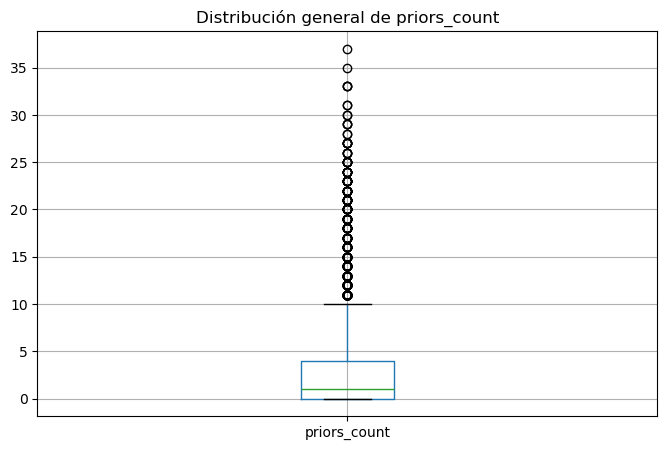

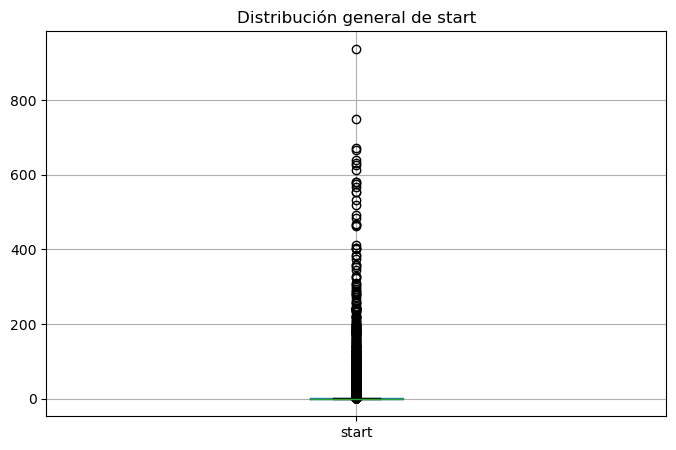

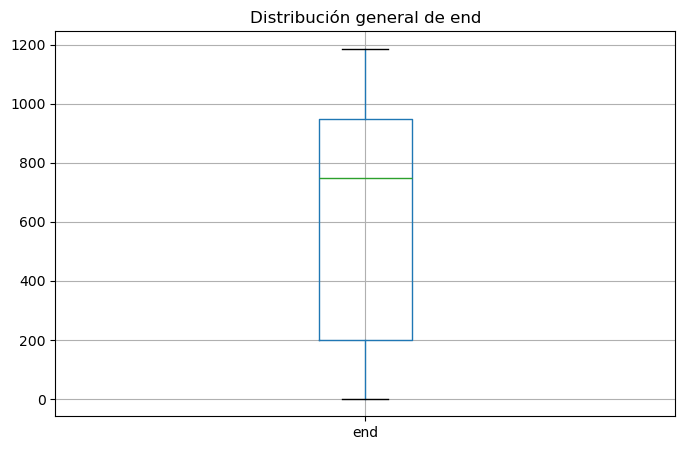

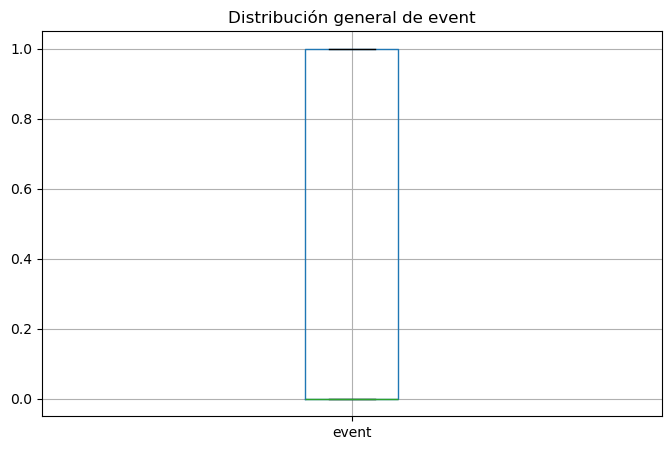

# Análisis bivariable

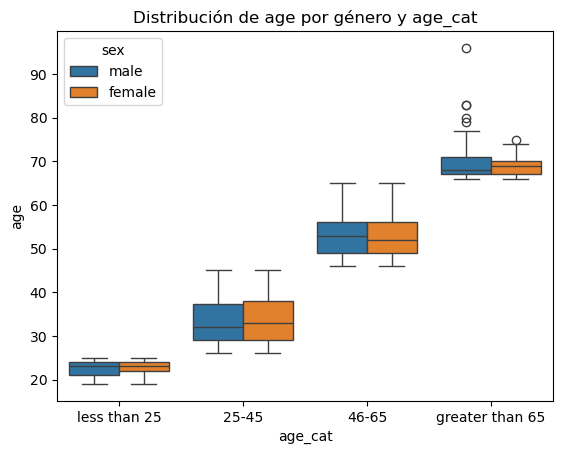

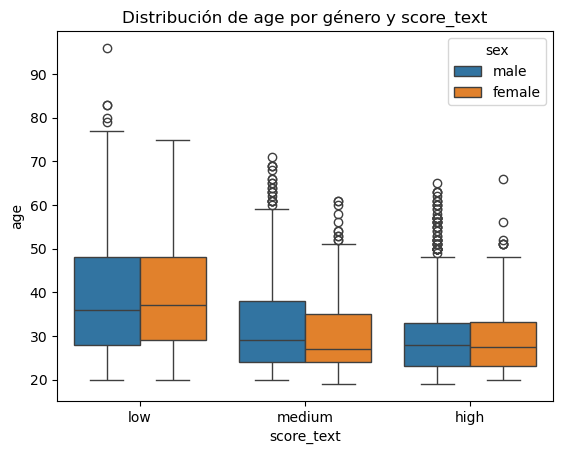

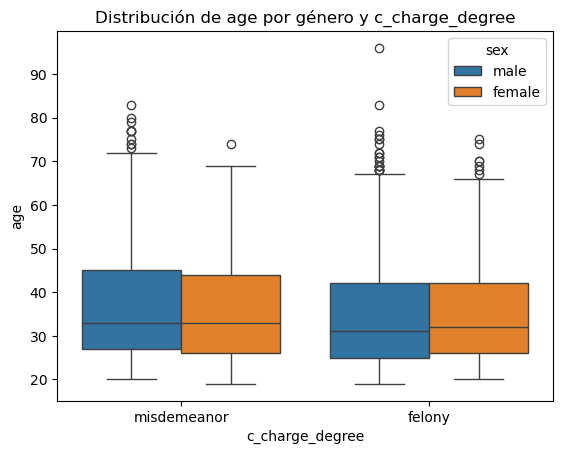

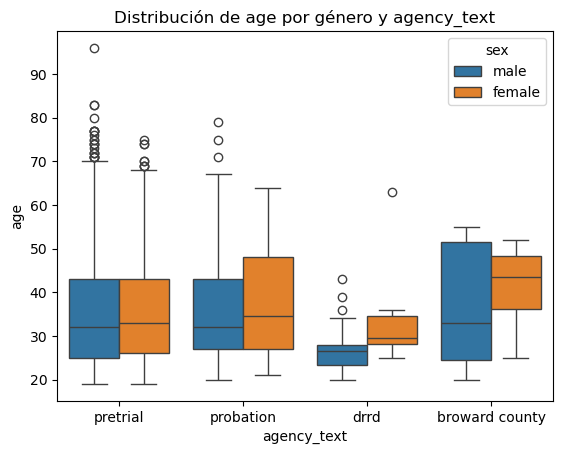

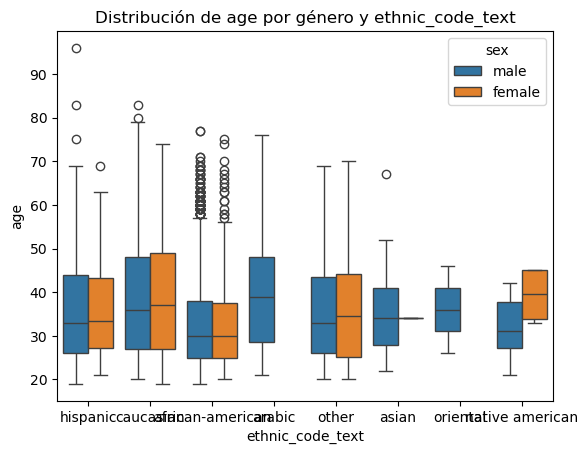

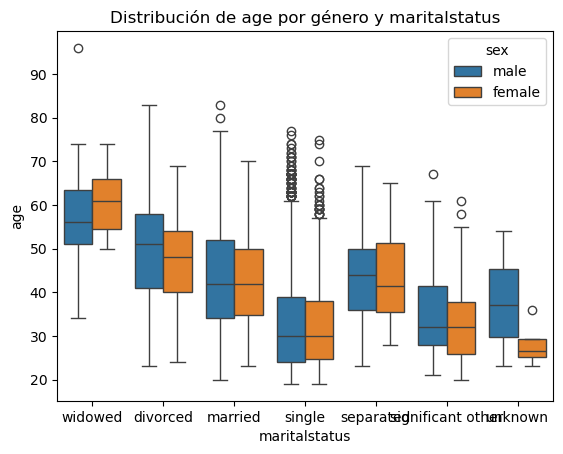

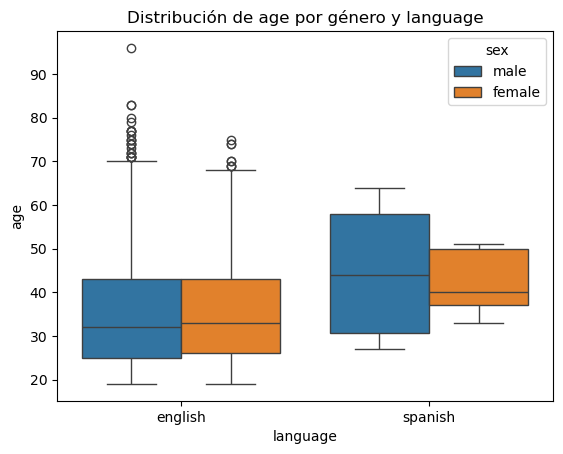

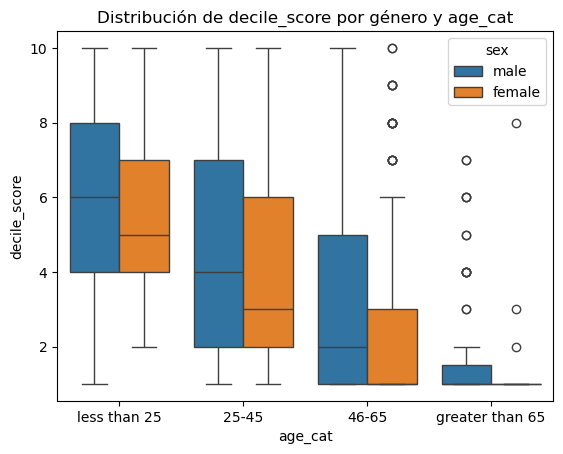

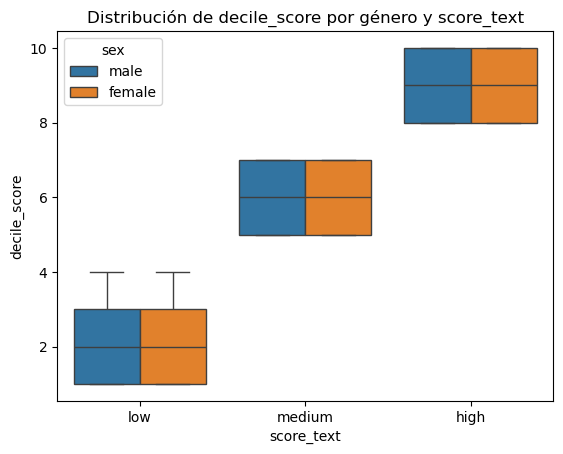

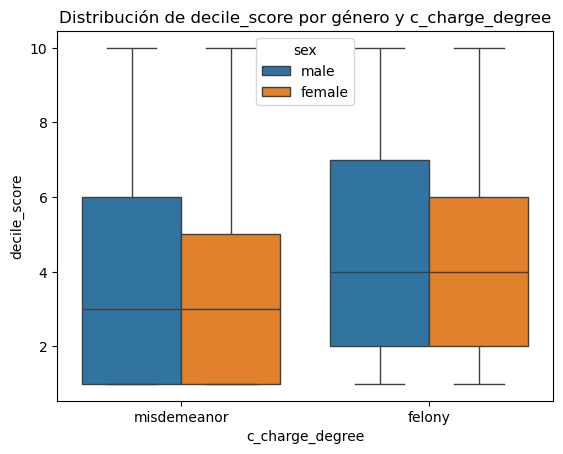

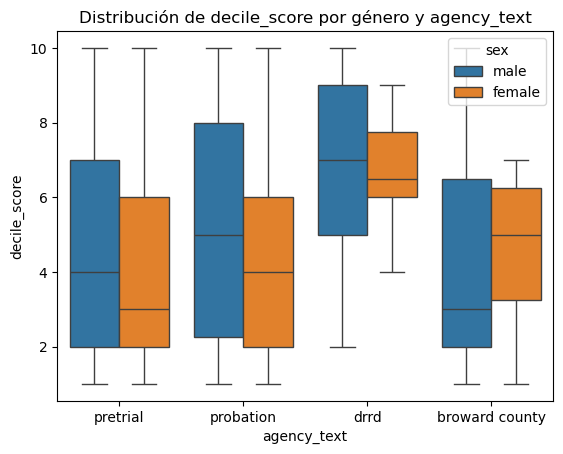

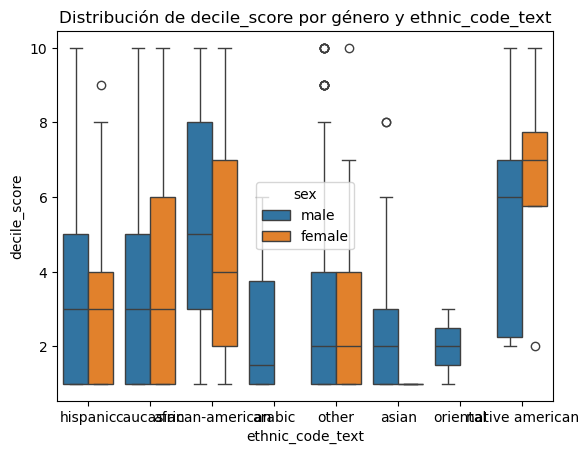

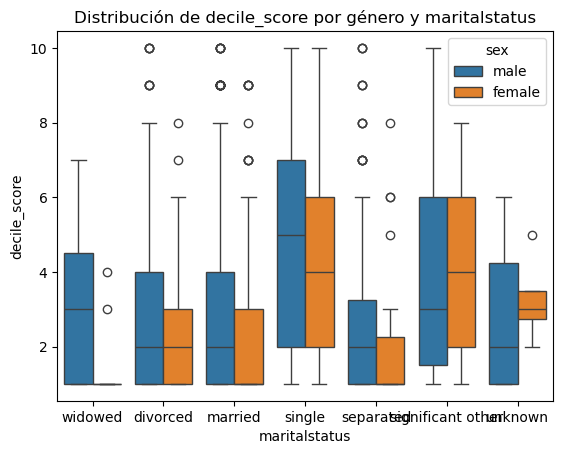

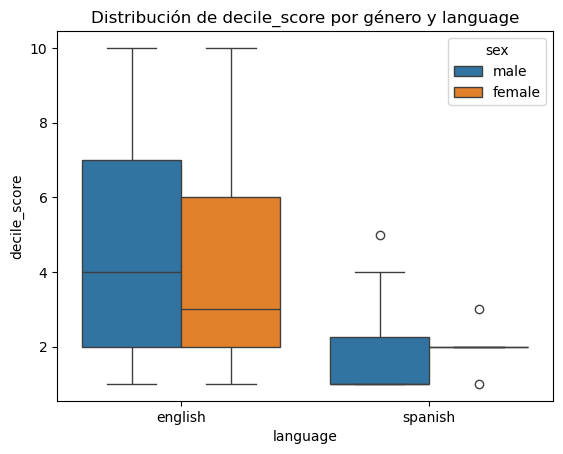

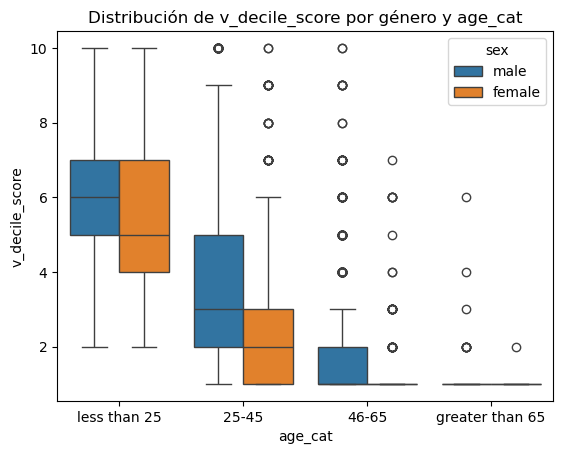

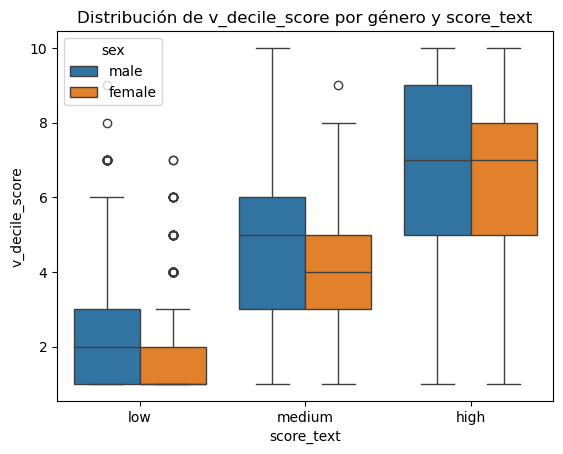

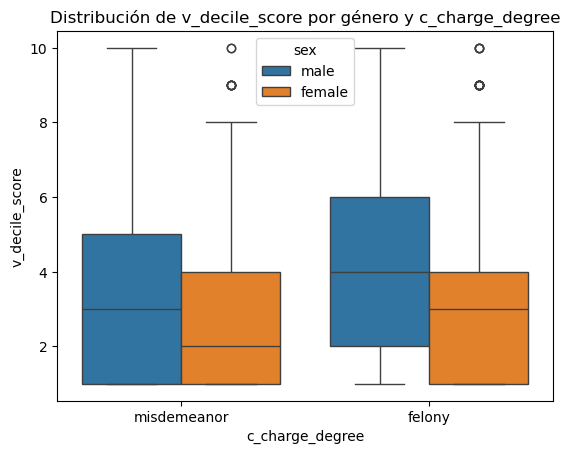

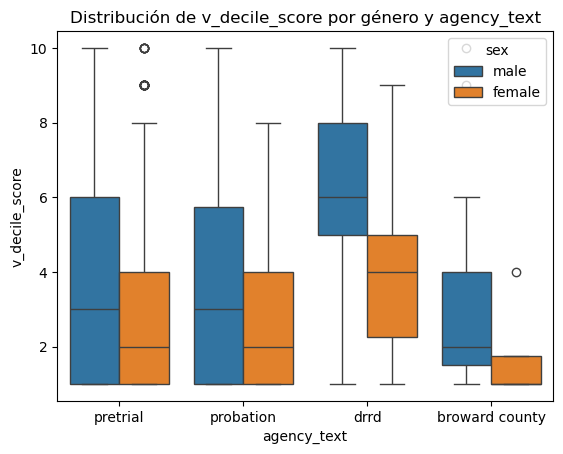

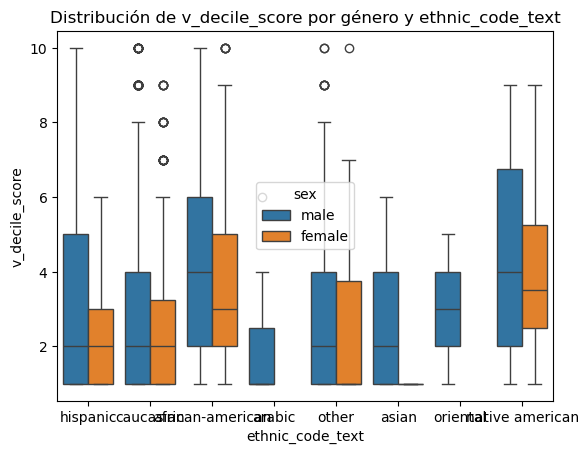

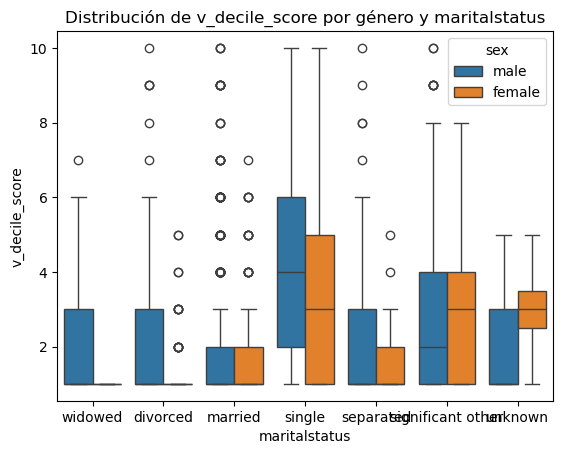

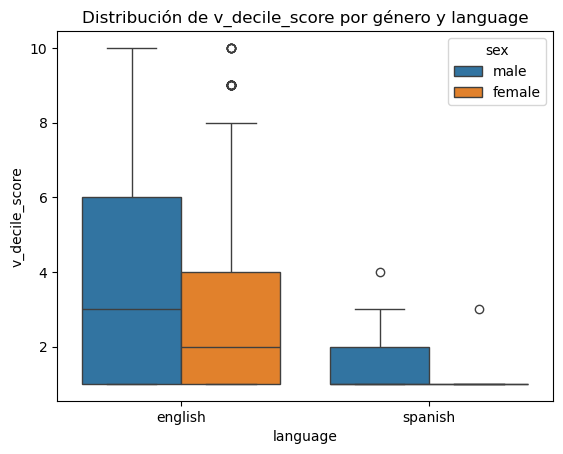

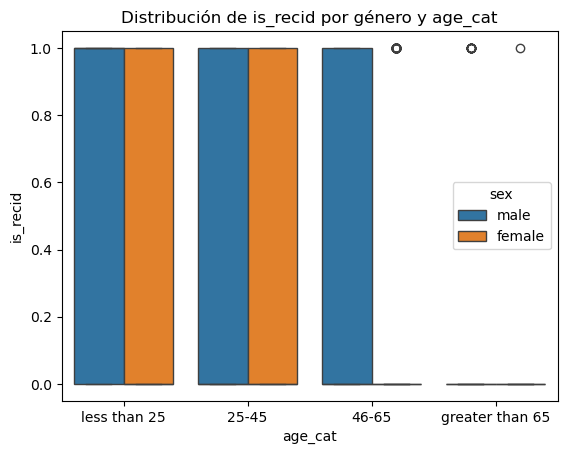

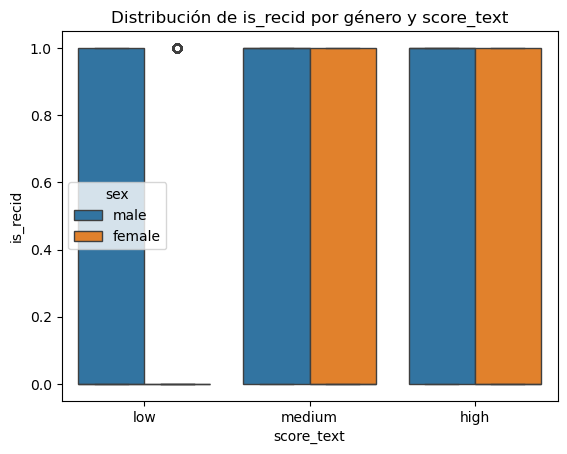

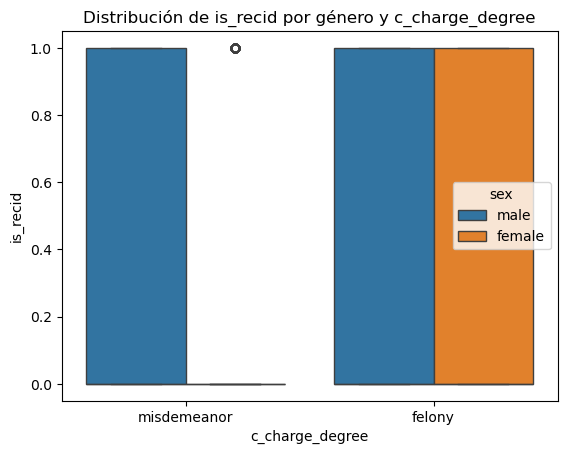

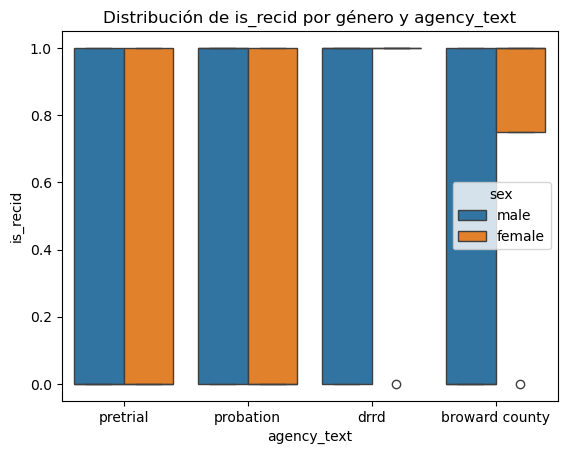

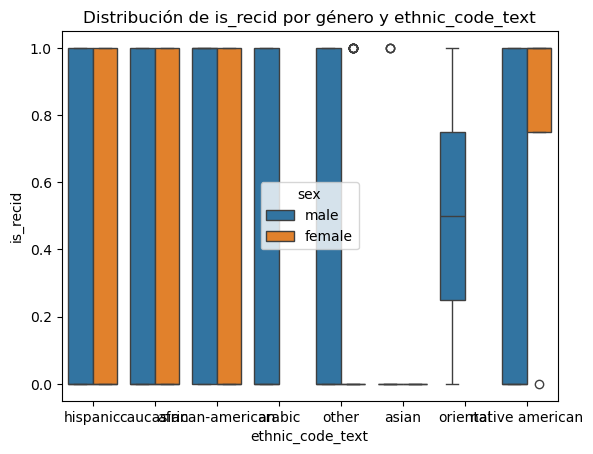

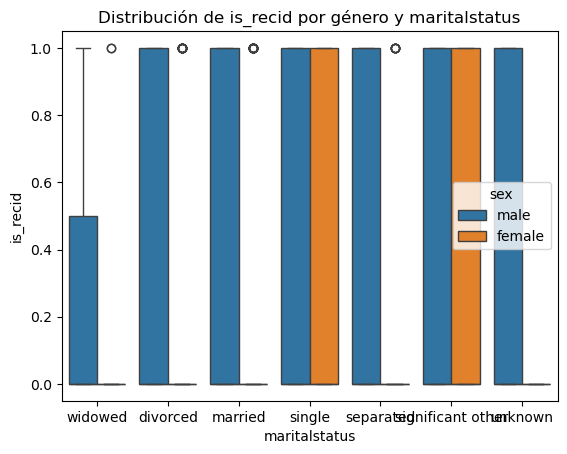

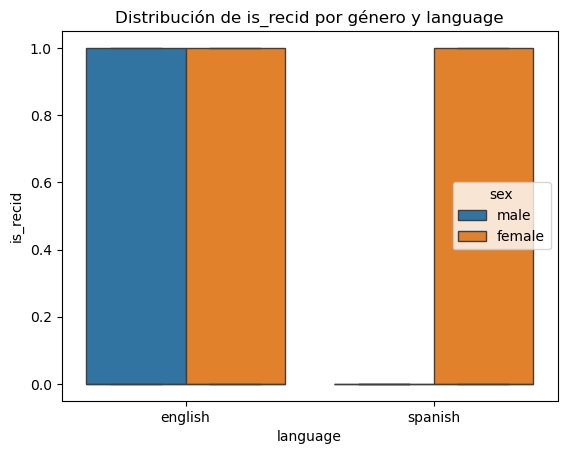

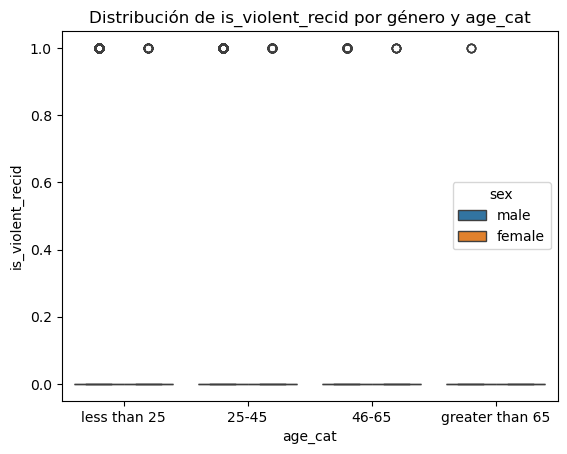

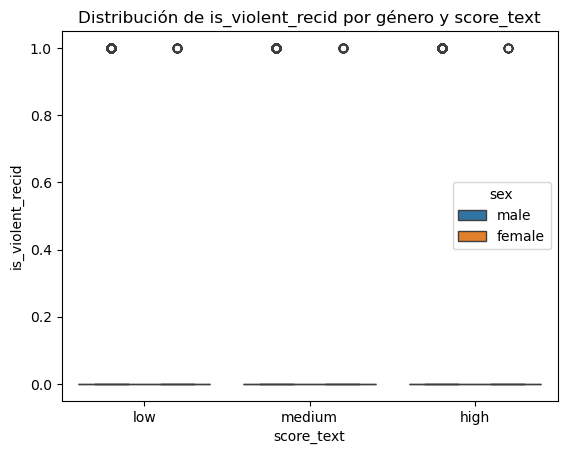

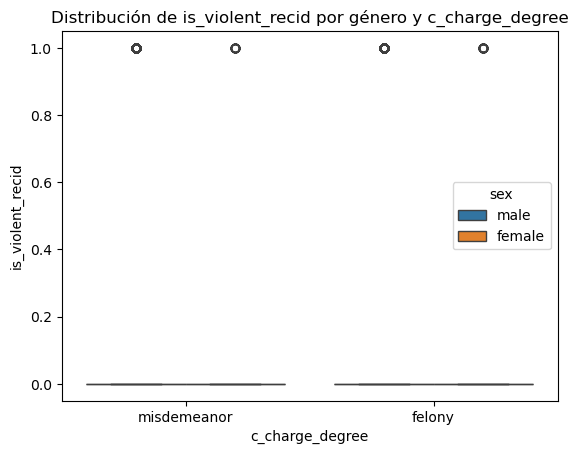

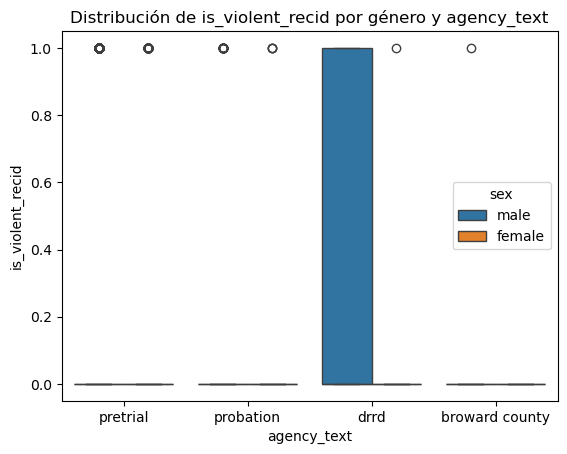

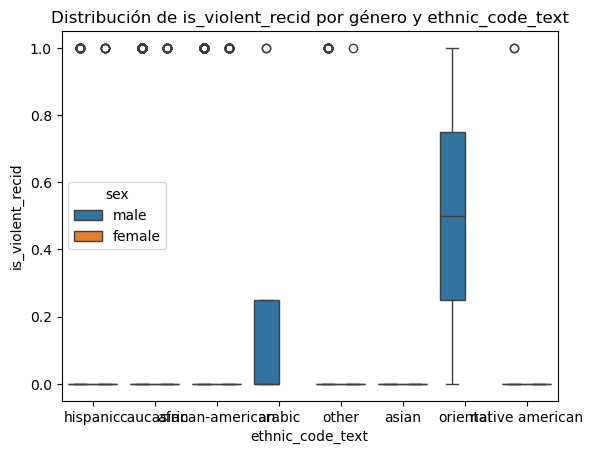

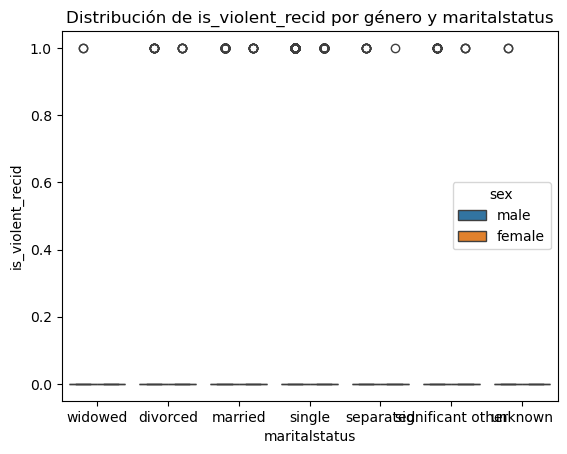

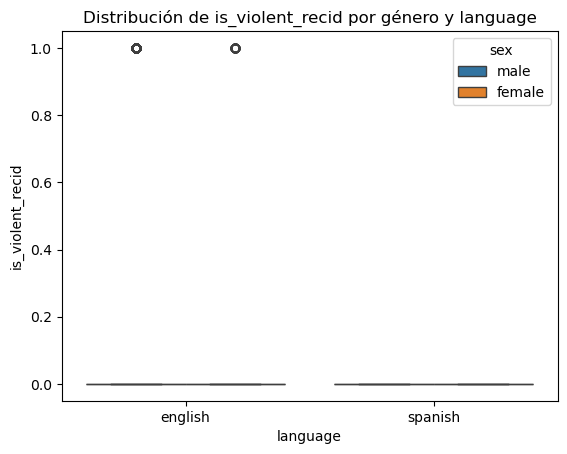

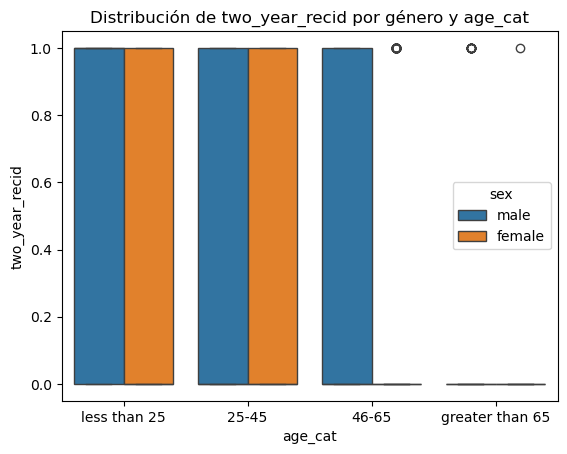

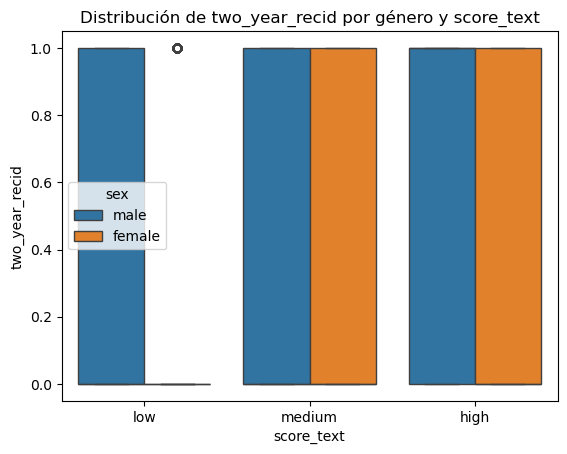

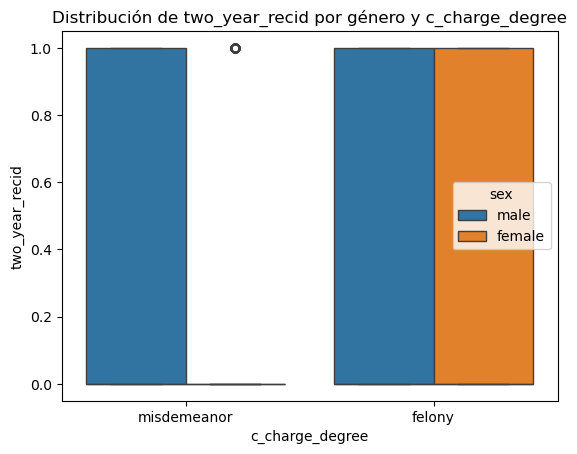

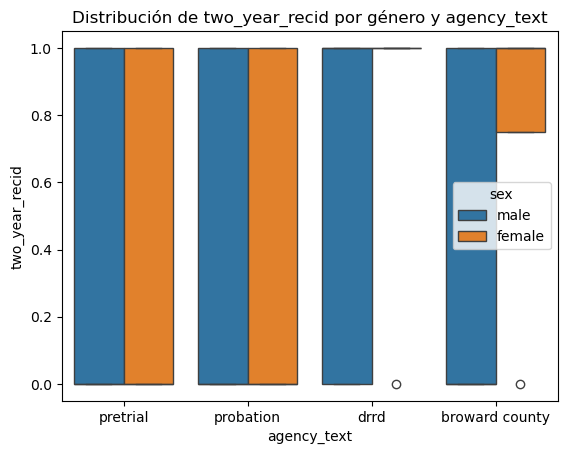

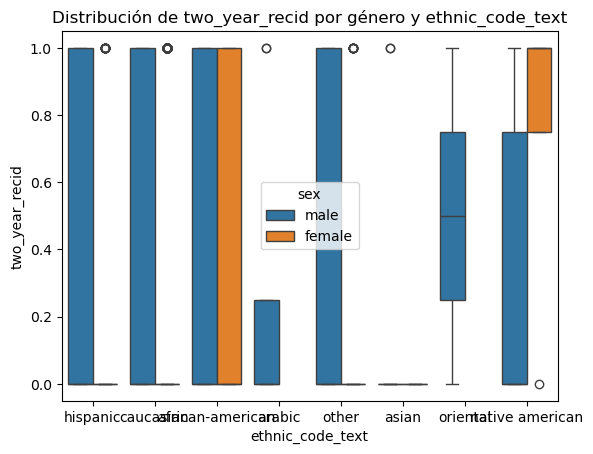

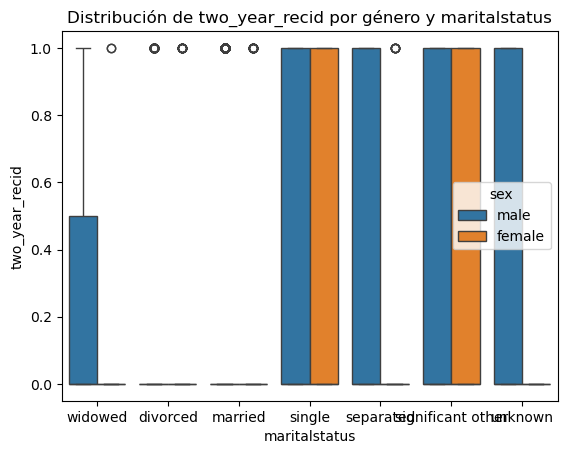

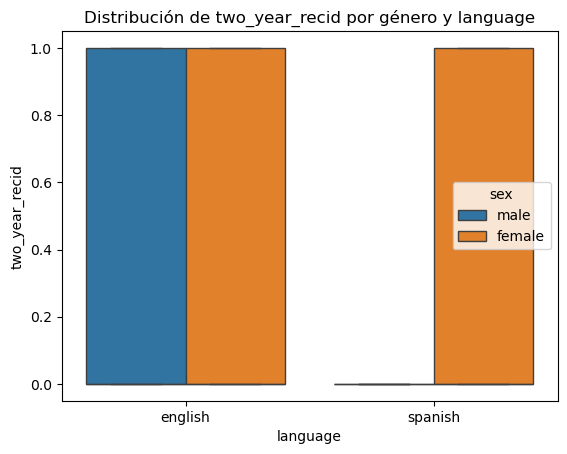

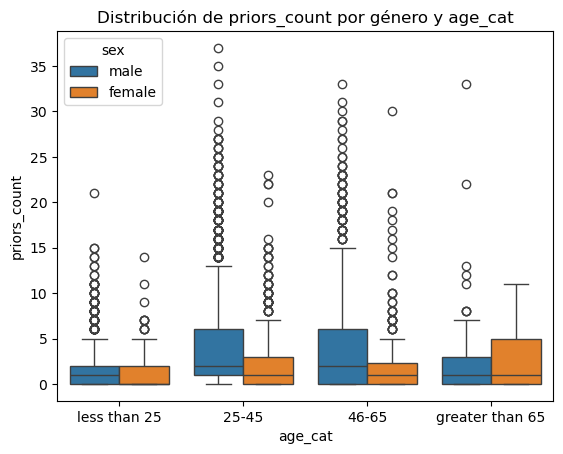

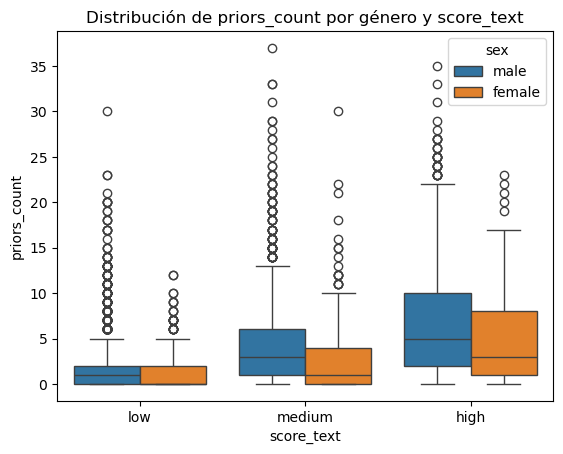

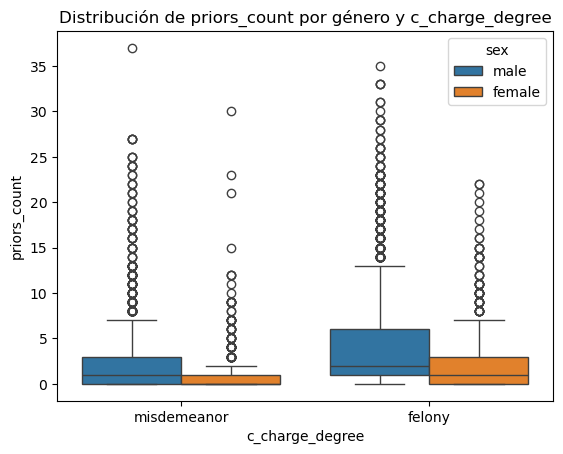

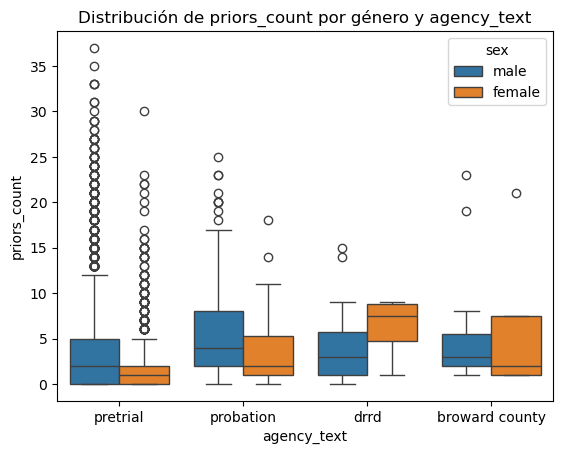

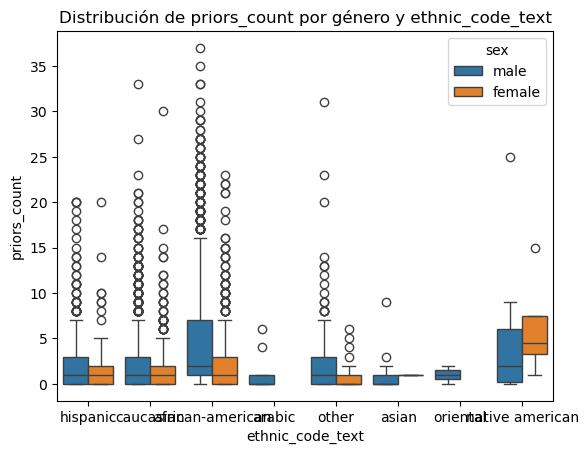

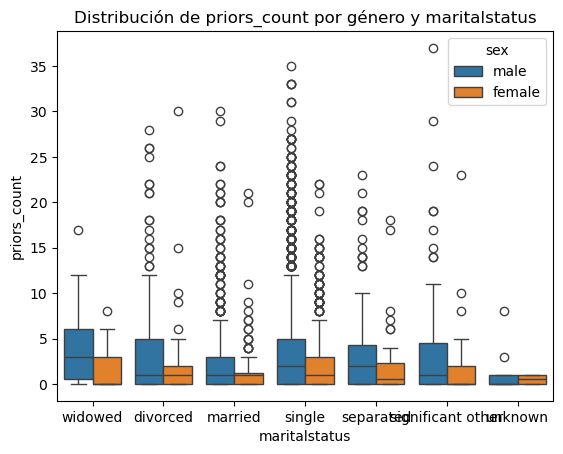

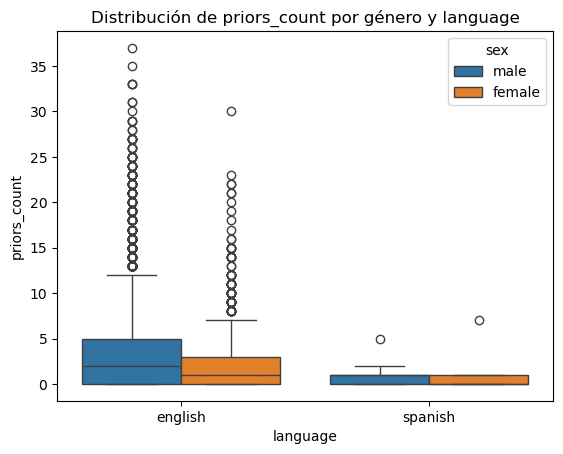

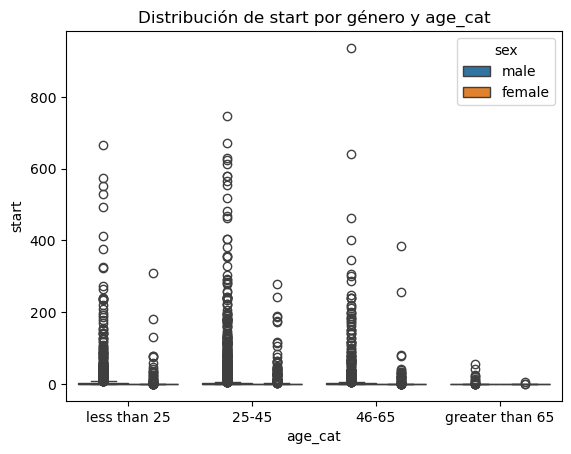

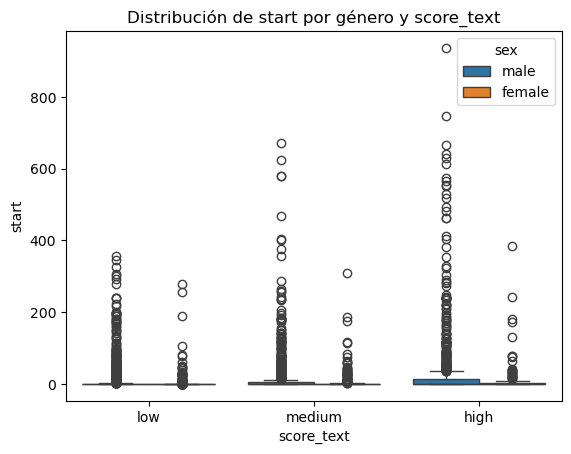

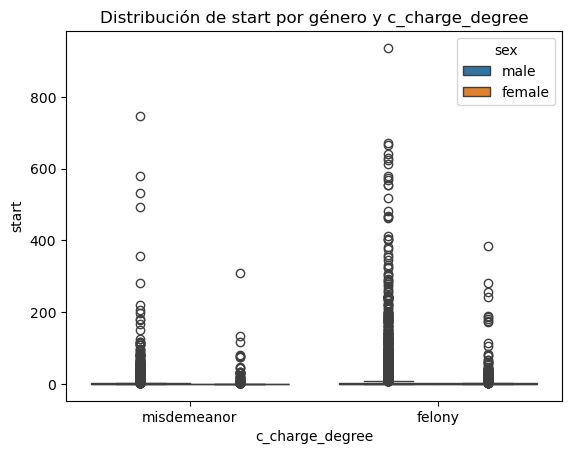

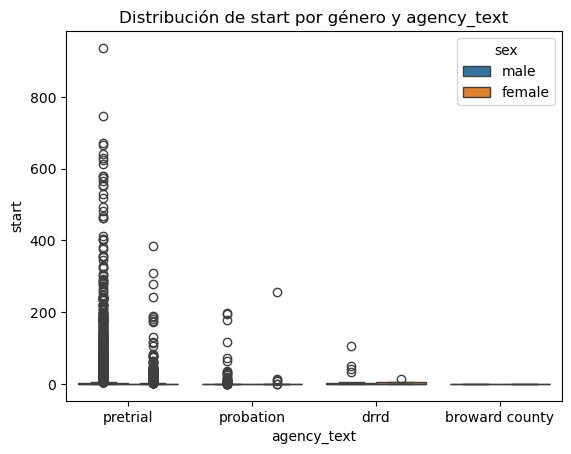

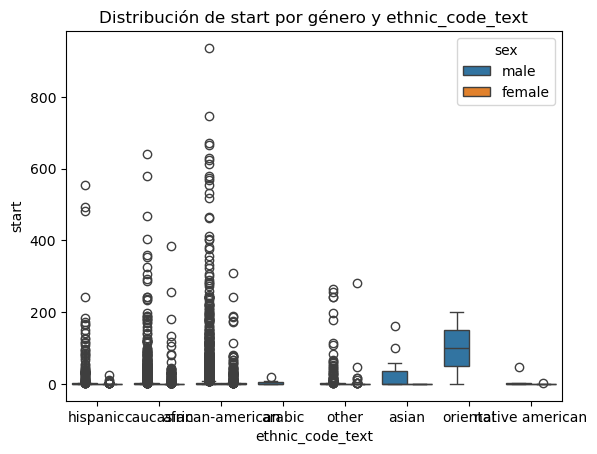

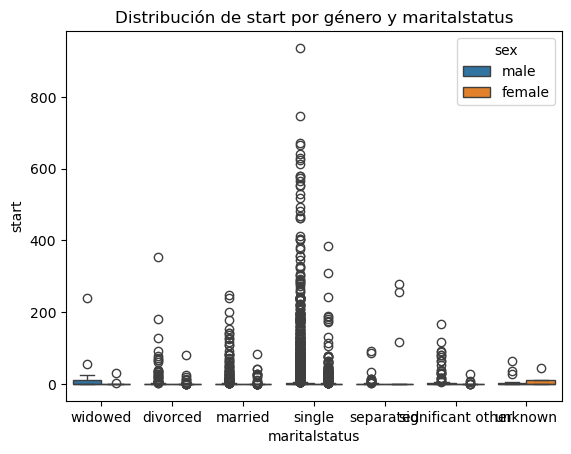

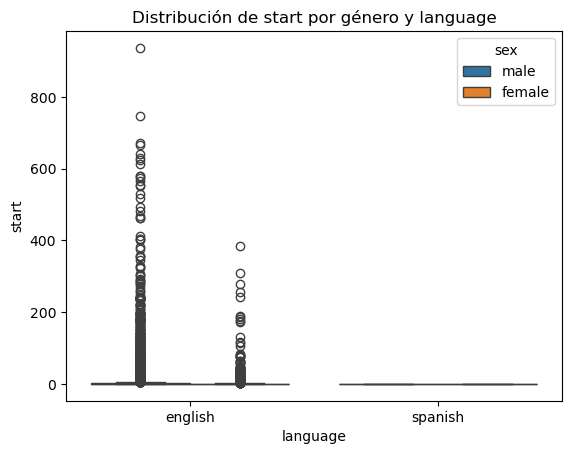

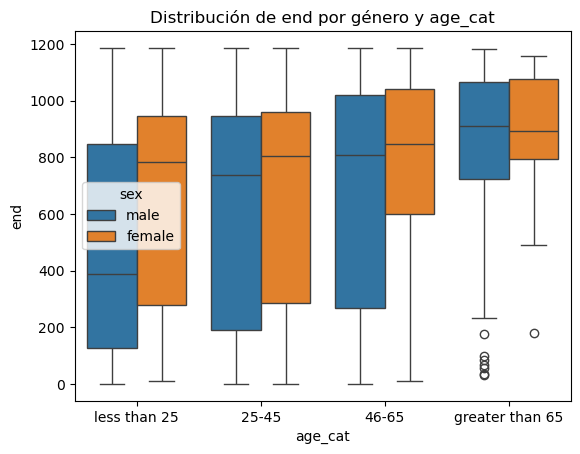

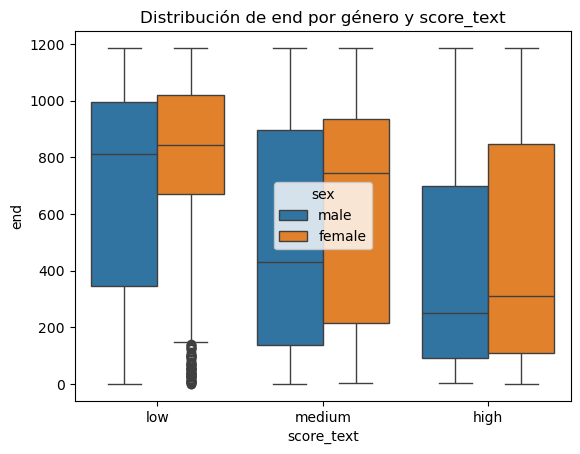

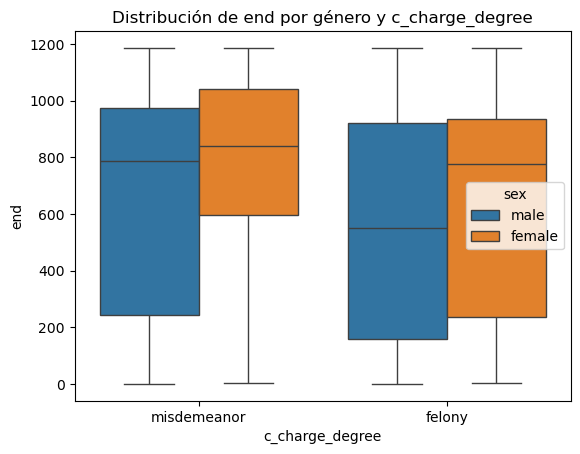

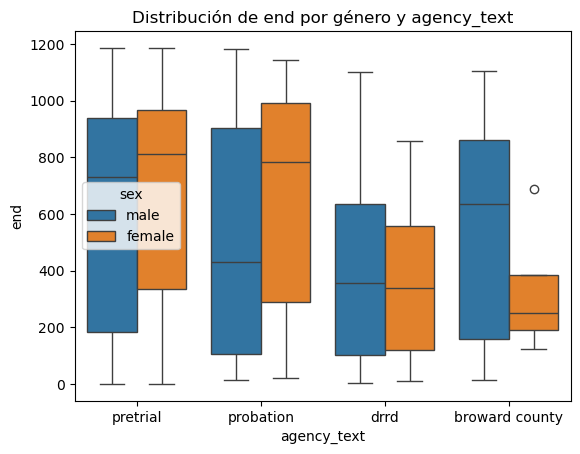

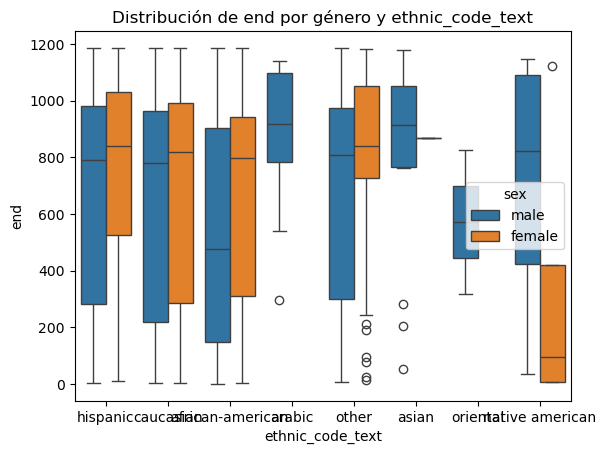

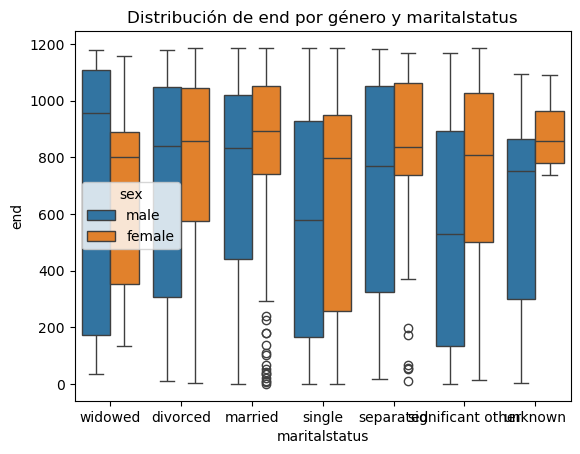

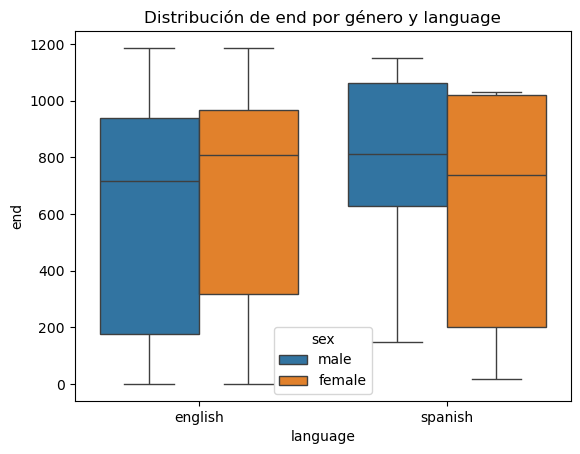

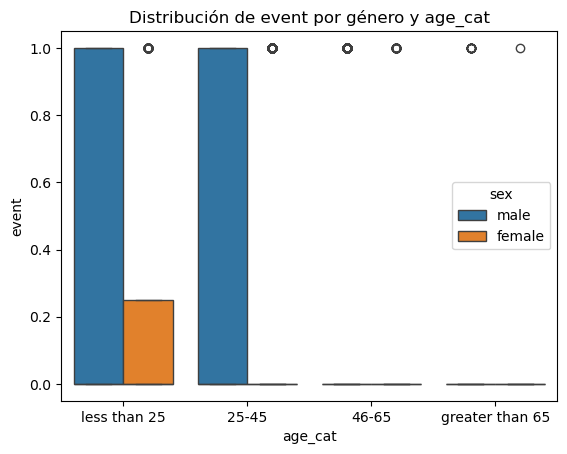

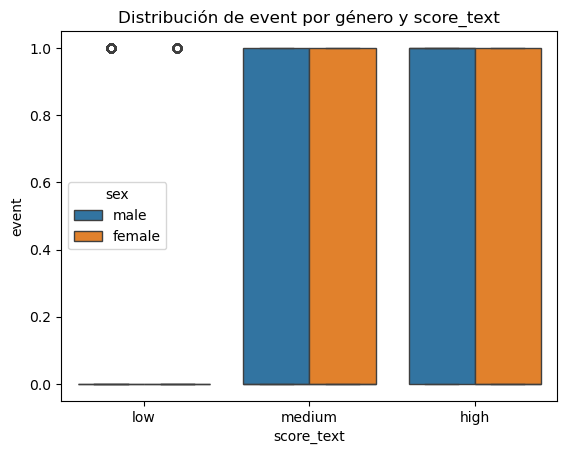

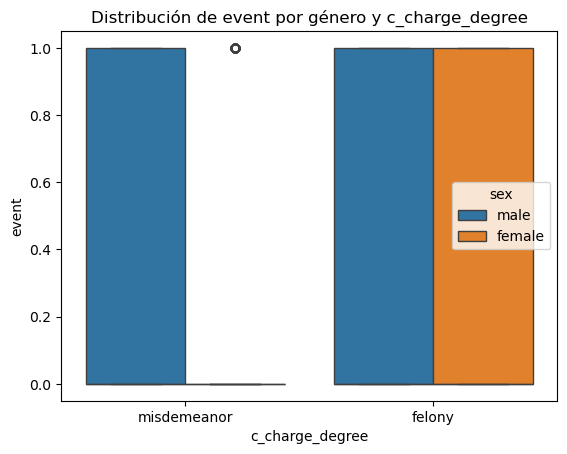

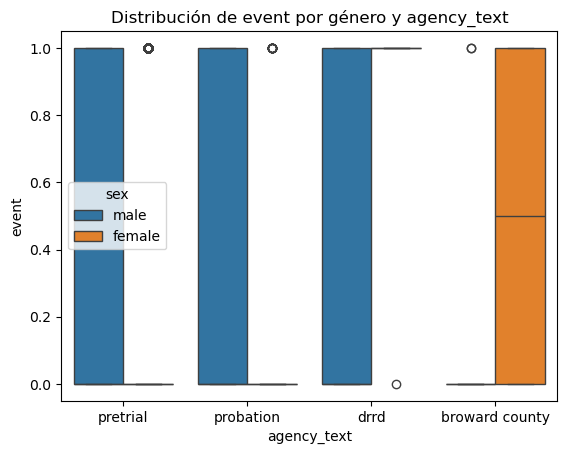

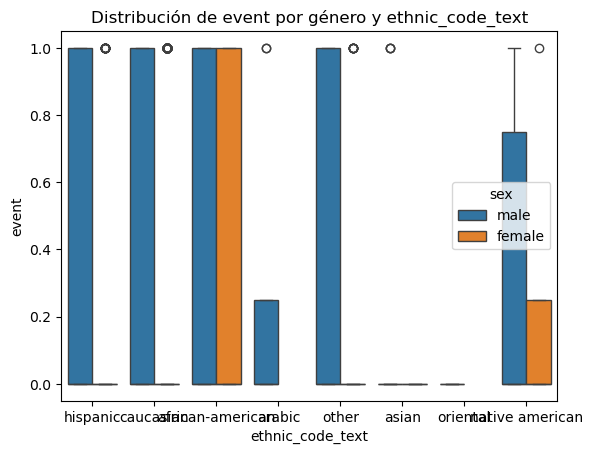

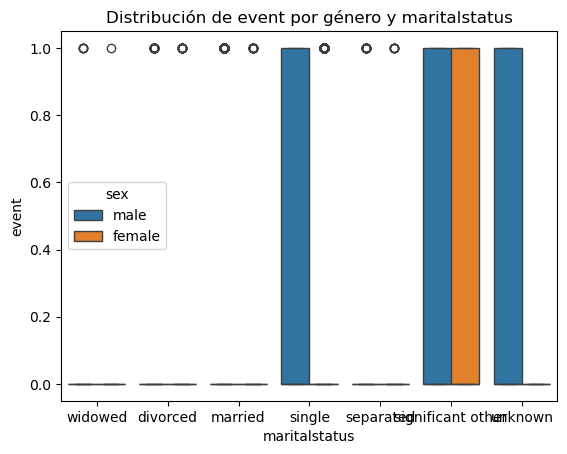

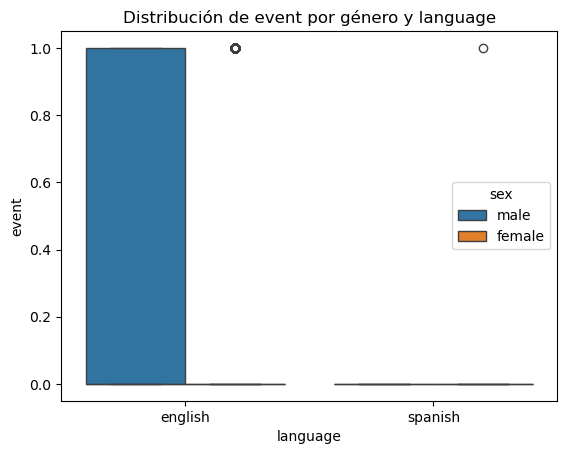

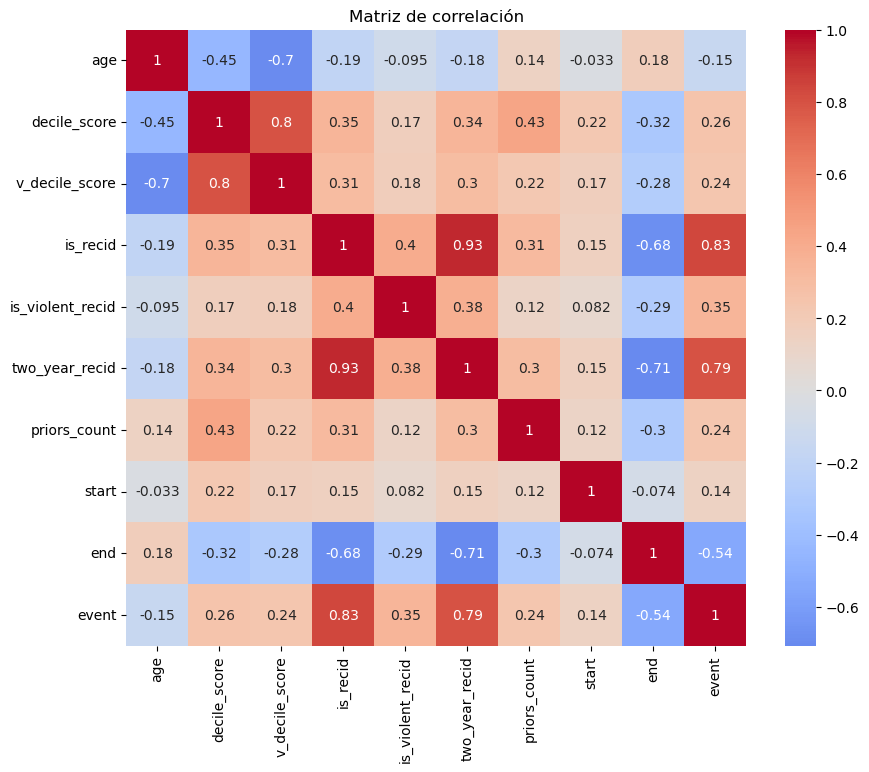


Crosstab entre sex y score_text


score_text,low,medium,high,All
sex,,,,
female,725,339,132,1196
male,2753,1236,952,4941
All,3478,1575,1084,6137



Crosstab entre sex y c_charge_degree


c_charge_degree,misdemeanor,felony,All
sex,,,
female,507,689,1196
male,1746,3195,4941
All,2253,3884,6137



Crosstab entre sex y ethnic_code_text


...

is_violent_recid,0,1,All
ethnic_code_text,,,
african-american,2743,360,3103
arabic,6,2,8
asian,18,0,18
caucasian,1942,152,2094
hispanic,523,42,565
native american,12,2,14
oriental,1,1,2
other,304,29,333
All,5549,588,6137



Crosstab entre maritalstatus y is_recid


is_recid,0,1,All
maritalstatus,,,
divorced,202,66,268
married,550,202,752
separated,102,38,140
significant other,102,85,187
single,2704,2032,4736
unknown,17,7,24
widowed,23,7,30
All,3700,2437,6137



Crosstab entre is_recid y is_violent_recid


is_violent_recid,0,1,All
is_recid,,,
0,3700,0,3700
1,1849,588,2437
All,5549,588,6137


In [18]:
eda(df)

In [ ]:
grupos = [
    grupo["priors_count"].values
    for nombre, grupo in df.groupby("ethnic_code_text")
]


F, p = f_oneway(*grupos)

print("F:", F)
print("p-value:", p)

F: 42.673021354981955
p-value: 3.4436026675729386e-59


In [12]:
# df_count = (
#         df['ethnic_code_text']
#         .value_counts()
#         .reset_index()
#     )